In [1]:
from Imports import *
from Plotting import *
from Helper import *
from Preprocessing import *

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../../QuGAN/data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


[ 9.99502919e-04-1.05270770e-03j  1.40533348e-04+8.98419847e-05j
 -2.63321716e-05-1.64705255e-04j -2.63321716e-05-1.64705255e-04j
  3.19226520e-02+1.88010351e-02j  2.01450672e-02+1.28786003e-02j
 -3.77464405e-03-2.36100432e-02j -3.77464405e-03-2.36100432e-02j
 -7.13715158e-04-1.38541562e-03j -1.96681396e-04+9.83332474e-05j
  2.04220478e-04+8.15291068e-05j  2.04220478e-04+8.15291068e-05j
 -1.55755299e-02+6.97080771e-03j -2.81937347e-02+1.40957993e-02j
  2.92744413e-02+1.16869722e-02j  2.92744413e-02+1.16869722e-02j
  6.29828112e-03-6.63354642e-03j  8.85558730e-04+5.66131490e-04j
 -1.65929900e-04-1.03787591e-03j -1.65929900e-04-1.03787591e-03j
  2.01157828e-01+1.18473095e-01j  1.26942397e-01+8.11533850e-02j
 -2.37855927e-02-1.48776644e-01j -2.37855927e-02-1.48776644e-01j
 -4.49741429e-03-8.73007660e-03j -1.23937079e-03+6.19638447e-04j
  1.28687767e-03+5.13748609e-04j  1.28687767e-03+5.13748609e-04j
 -9.81478534e-02+4.39259414e-02j -1.77660378e-01+8.88234594e-02j
  1.84470358e-01+7.364444

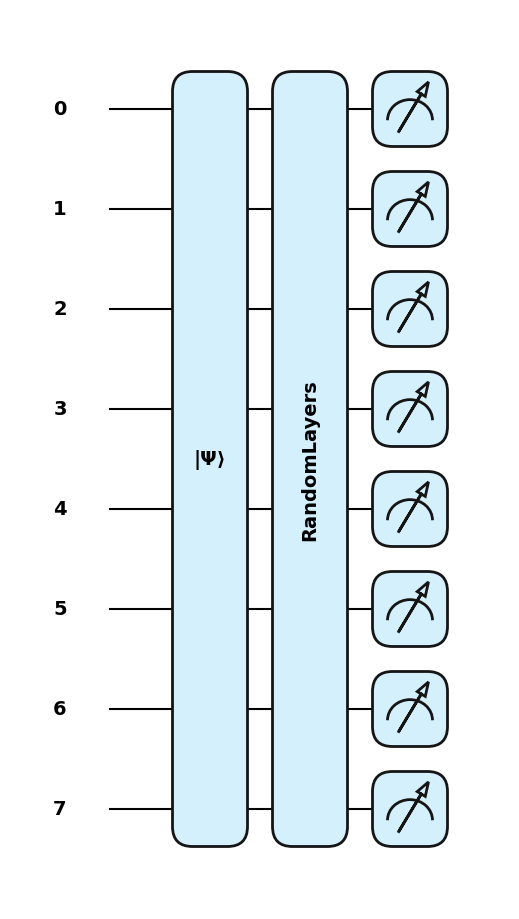

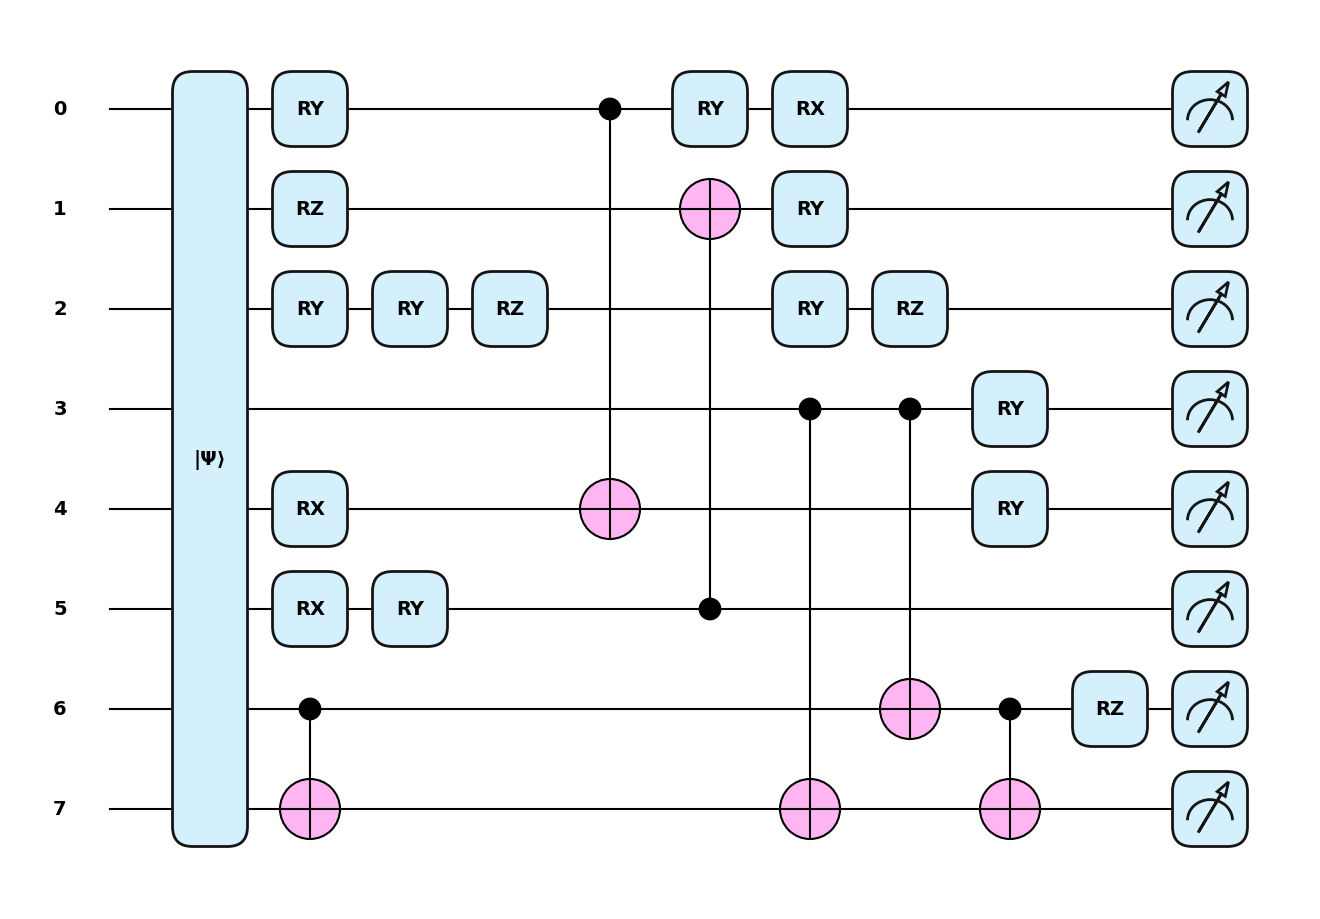

In [3]:
dev = qml.device("default.qubit", wires=8)
n_layers = 1

# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, 16))

@qml.qnode(dev)
def quantum_feature_embedding(f, phi, interface="torch", diff_method="backprop", cachesize=1000000):
    qml.AmplitudeEmbedding(features=f, wires=range(8), normalize=True, pad_with=0.)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(8)), seed = 6)

    # Measurement producing classical output values
    return qml.state()
    # return [qml.expval(qml.PauliZ(j)) for j in range(4)]

state = quantum_feature_embedding(f=[1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4], phi=rand_params)
print(state)

def quantum_feature_embedding_batch(x_batch, phi, device="cuda"):
    """
    Applies quantum_feature_embedding_single to a batch of inputs.

    Args:
        x_batch (torch.Tensor): (B, D) input batch.
        phi (np.ndarray or torch.Tensor): parameters for RandomLayers.
        device (str): Device to return output on.

    Returns:
        torch.Tensor: Output of shape (B, 2 ** n_qubits)
    """
    outputs = []
    for x in x_batch:
        result = quantum_feature_embedding(x, phi)
        result_tensor = result.real.to(device)
        outputs.append(result_tensor)

    return torch.stack(outputs)

sample = torch.randn(16, 9).to("cuda")  # Example batch
phi_tensor = torch.tensor(rand_params, dtype=torch.float32)

output = quantum_feature_embedding_batch(sample, phi_tensor)
print(output.shape)

class quantum_feature_embedding_batch(nn.Module):
    def __init__(self, device="cuda"):
        super().__init__()
        self.phi = nn.Parameter(torch.tensor(np.random.uniform(high=2 * np.pi, size=(n_layers, 3)), dtype=torch.float32))
    
    def forward(self, x_batch):
        phi = self.phi
        outputs = []
        for x in x_batch:
            result = quantum_feature_embedding(x, phi)
            result_tensor = result.real.to(device)
            outputs.append(result_tensor)
    
        return torch.stack(outputs)

qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(quantum_feature_embedding)(f=[1/4]*9, phi=rand_params)
fig, ax = qml.draw_mpl(quantum_feature_embedding, level="device")(f=[1/4]*9, phi=rand_params)

In [4]:
# Generator with Quantum Layer
class Generator(nn.Module):
    def __init__(self, latent_dim=9):
        super().__init__()

        self.noise = GaussianNoise(sigma=0.1)
        
        self.feature_gen = quantum_feature_embedding_batch()

        self.image_gen1 = nn.Sequential(
            self.noise,
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1x1 → 2x2
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 2x2 → 4x4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 4x4 → 8x8
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )

        self.image_gen4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 8x8 → 16x16
            nn.Sigmoid()
        )

    def forward(self, z_feat):
        img = self.feature_gen(z_feat).float()
        # print(img.shape)
        img = img.view(-1, 256, 1, 1)
        # print(img.shape)
        img = self.image_gen1(img)
        # print(img.shape)
        img = self.image_gen2(img)
        # print(img.shape)
        img = self.image_gen3(img)
        # print(img.shape)
        img = self.image_gen4(img)
        # print(img.shape)
        img = soft_threshold(img, threshold=0.001, sharpness=1000.0)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
                # Flattened image: 16x16 = 256
        self.image_encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Flatten()
        )

        self.feature_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )

        # Dynamically get input dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16, 16)
            flat_dim = self.image_encoder(dummy).shape[1] + 64

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
   
    def forward(self, img, features):
        img_encoded = self.image_encoder(img)
        feat_encoded = self.feature_encoder(features)
        combined = torch.cat((img_encoded, feat_encoded), dim=1)

        # print(img_encoded.shape)
        # print(feat_encoded.shape)
        # print(combined.shape[-1])

        prob = self.classifier(combined)

        return prob  # Shape: (batch_size, 1)

Image shape: torch.Size([43633, 16, 16])
dR Mean: torch.Size([43633])
dR STD: torch.Size([43633])
Pixel Mean: torch.Size([43633])
Pixel STD: torch.Size([43633])
ΔR min: 0.0
ΔR max: 2.265674114227295
ΔR mean min: 0.0042752958834171295
ΔR mean max: 0.01479329913854599
ΔR std min: 0.02181866206228733
ΔR std max: 0.14948226511478424
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0029057813808321953
Pixel mean max: 0.004424060694873333
Pixel std min: 0.009593216702342033
Pixel std max: 0.06260580569505692


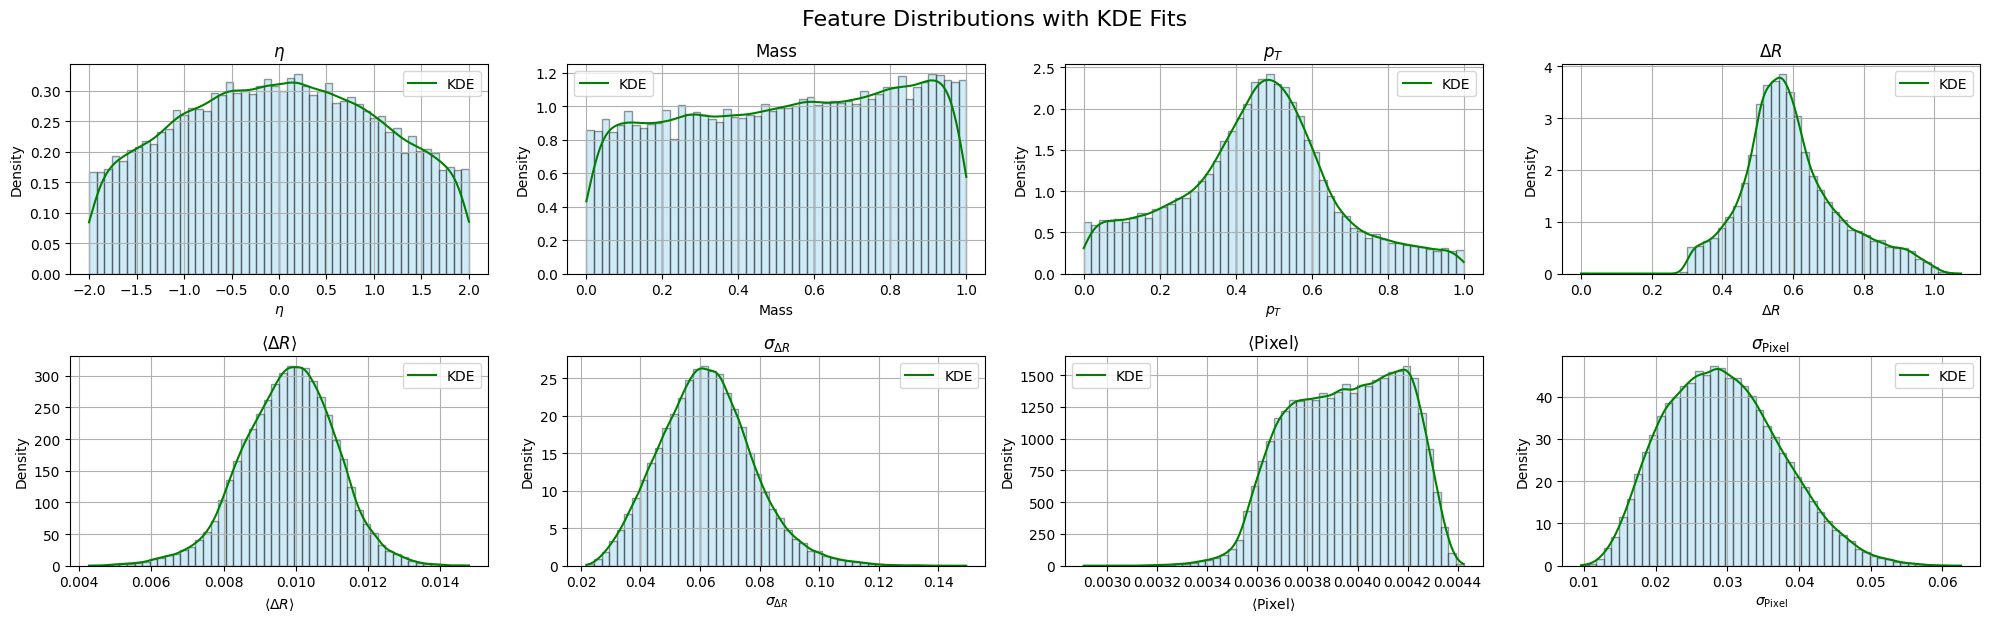

Number of samples: 43633
Image shape: torch.Size([43633, 16, 16])
Feature shape: torch.Size([43633, 9])


In [5]:
batch_size = 128
n_events = int(.05 * jet_mass_data['image'].shape[0])

dataset = JetDataset(jet_mass_data, n_events)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

kdes = feature_distributions(dataset)

print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

In [6]:
latent_dim = 256
lr = 10e-4
n_epochs = 100
num = 4

generator = Generator(latent_dim).cuda()
discriminator = Discriminator().cuda()

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.9, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.9, 0.999))


scheduler_G = CosineAnnealingLR(optimizer_G, T_max=n_epochs, eta_min=1e-4)
scheduler_D = CosineAnnealingLR(optimizer_D, T_max=n_epochs, eta_min=1e-4)

g_losses = []
d_losses = []

# Image shape: (16, 16)
H, W = (16, 16)
center_x, center_y = (W - 1) / 2, (H - 1) / 2

# Coordinate grid
x_coords, y_coords = torch.meshgrid(
    torch.arange(W, dtype=torch.float32),
    torch.arange(H, dtype=torch.float32),
    indexing='ij')

# Distance from center
dists = (torch.sqrt((x_coords - center_x) ** 2 + (y_coords - center_y) ** 2)).cuda()
dists = dists.unsqueeze(0)  # [1, 16, 16]

tracked_fake_dR_mean = []
tracked_fake_dR_std = []
tracked_fake_pixel_mean = []
tracked_fake_pixel_std = []

tracked_real_dR_mean = []
tracked_real_dR_std = []
tracked_real_pixel_mean = []
tracked_real_pixel_std = []

In [7]:
## Load a previous model
# Replace with the desired filename
load = True
if load:
    load_path = "models/Q_gan_rand_layers_m21_1016.pt"
    
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    tracked_fake_dR_mean = checkpoint["tracked_fake_dR_mean"]
    tracked_fake_dR_std = checkpoint["tracked_fake_dR_std"]
    tracked_fake_pixel_mean = checkpoint["tracked_fake_pixel_mean"]
    tracked_fake_pixel_std = checkpoint["tracked_fake_pixel_std"]
    
    tracked_real_dR_mean = checkpoint["tracked_real_dR_mean"]
    tracked_real_dR_std = checkpoint["tracked_real_dR_std"]
    tracked_real_pixel_mean = checkpoint["tracked_real_pixel_mean"]
    tracked_real_pixel_std = checkpoint["tracked_real_pixel_std"]
    
    print(f"Loaded model from {load_path}")

Loaded model from models/Q_gan_rand_layers_best_m18_1831.pt


[Epoch 1/100] [D loss: 0.6030] [G loss: 0.4112] [Validity_loss: 0.5784] 
 [Stat_loss: 0.0056] [NNZ_loss: 0.0661]
Sample feature coding: [ 1.         -0.49525064  0.21359083  0.10965242  0.62329435  0.01061668
  0.05113206  0.0037699   0.01832645]


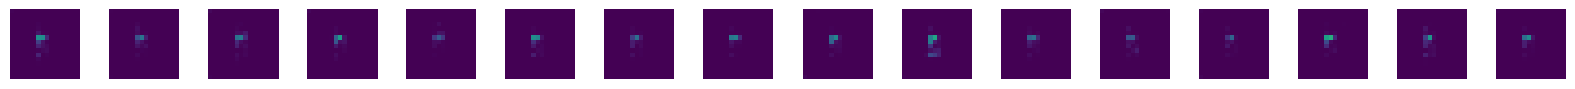

Model and statistics saved to models/Q_gan_rand_layers_temp.pt
[Epoch 2/100] [D loss: 0.7252] [G loss: 0.0550] [Validity_loss: 0.6486] 
 [Stat_loss: 0.0026] [NNZ_loss: 0.0475]
Sample feature coding: [ 0.         -0.18478902  0.9354909   0.28040007  0.9339973   0.00931575
  0.03328535  0.00367294  0.0257866 ]


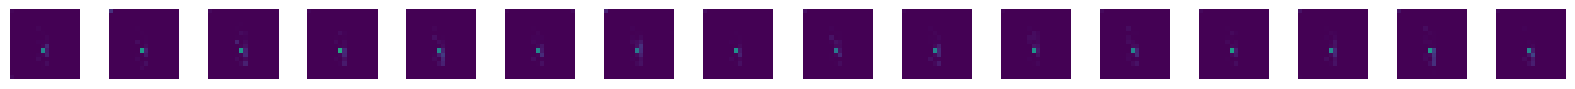

[Epoch 3/100] [D loss: 0.5425] [G loss: 0.0884] [Validity_loss: 0.7415] 
 [Stat_loss: 0.0092] [NNZ_loss: 0.0556]
Sample feature coding: [ 0.         -0.8376863   0.30452648  0.3229105   0.5983877   0.00977184
  0.06689451  0.00396601  0.02846706]


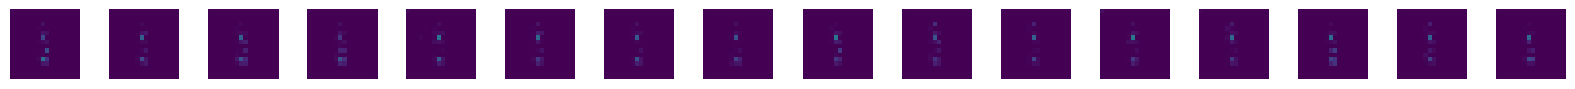

[Epoch 4/100] [D loss: 0.7220] [G loss: 0.0678] [Validity_loss: 0.6994] 
 [Stat_loss: 0.0021] [NNZ_loss: 0.0625]
Sample feature coding: [0.         0.8953539  0.25377724 0.9332664  0.8015303  0.00935371
 0.07092061 0.00394256 0.02462486]


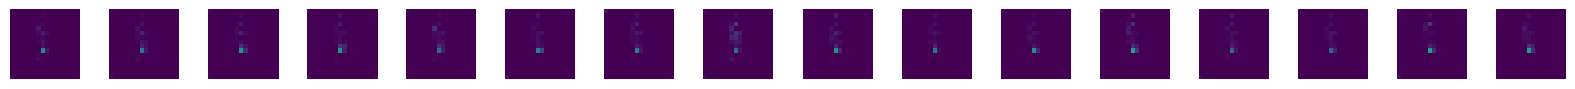

[Epoch 5/100] [D loss: 0.6933] [G loss: 0.0705] [Validity_loss: 0.7417] 
 [Stat_loss: 0.0243] [NNZ_loss: 0.0603]
Sample feature coding: [ 1.         -1.0096192   0.8155209   0.020425    0.66768306  0.01133295
  0.05870932  0.00418141  0.03083523]


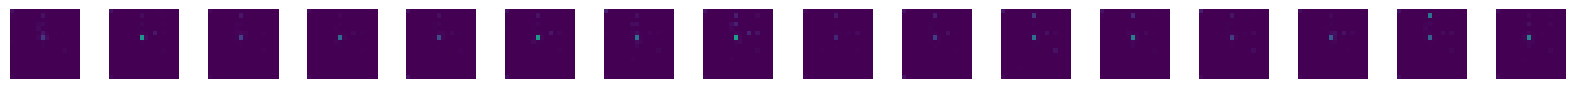

[Epoch 6/100] [D loss: 0.6931] [G loss: 0.0723] [Validity_loss: 0.6436] 
 [Stat_loss: 0.0428] [NNZ_loss: 0.0547]
Sample feature coding: [0.         2.0039032  0.6330768  0.17832553 0.61992544 0.00932625
 0.06841101 0.00396519 0.02361821]


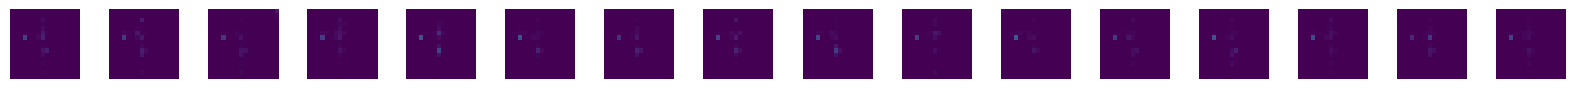

[Epoch 7/100] [D loss: 0.6933] [G loss: 0.0709] [Validity_loss: 0.7117] 
 [Stat_loss: 0.0040] [NNZ_loss: 0.0428]
Sample feature coding: [0.         1.9014006  0.7022089  0.61763185 0.54745144 0.00920422
 0.04183087 0.00391454 0.02125059]


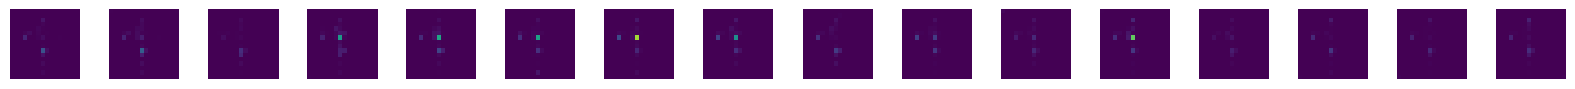

[Epoch 8/100] [D loss: 0.6874] [G loss: 0.0725] [Validity_loss: 0.6229] 
 [Stat_loss: 0.0163] [NNZ_loss: 0.0595]
Sample feature coding: [ 1.         -1.4236684   0.8495287   0.19852626  0.5391484   0.00982059
  0.06791791  0.00416001  0.03140411]


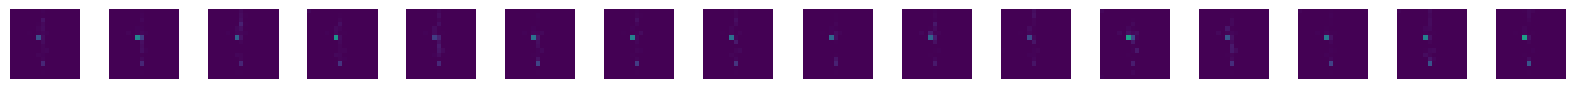

[Epoch 9/100] [D loss: 0.6846] [G loss: 0.0727] [Validity_loss: 0.5100] 
 [Stat_loss: 0.0580] [NNZ_loss: 0.0667]
Sample feature coding: [1.         0.33806565 0.99506766 0.48009992 0.46454713 0.01209154
 0.07251336 0.00383053 0.01443881]


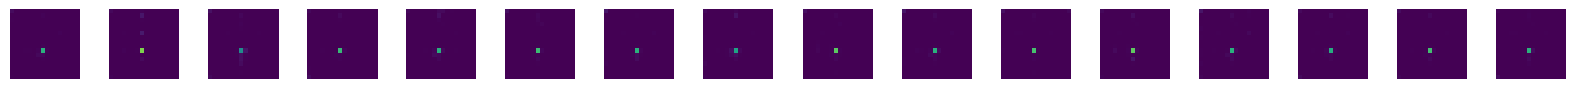

[Epoch 10/100] [D loss: 0.6917] [G loss: 0.0700] [Validity_loss: 0.7730] 
 [Stat_loss: 0.0016] [NNZ_loss: 0.0503]
Sample feature coding: [0.         1.5734888  0.7224393  0.5918706  0.8496224  0.01069353
 0.05908692 0.00406737 0.0288734 ]


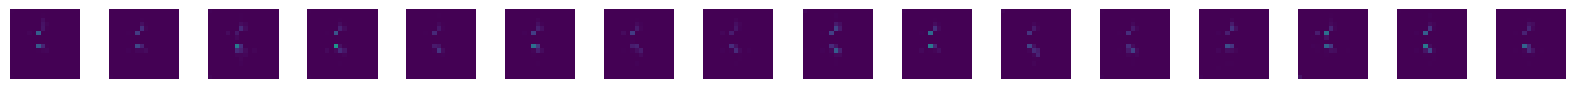

[Epoch 11/100] [D loss: 0.6831] [G loss: 0.0742] [Validity_loss: 0.6605] 
 [Stat_loss: 0.0023] [NNZ_loss: 0.0535]
Sample feature coding: [0.         0.76225686 0.32647777 0.4757813  0.6791985  0.00952324
 0.07035706 0.003967   0.03481077]


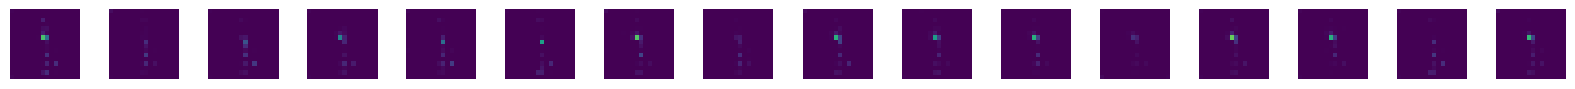

Model and statistics saved to models/Q_gan_rand_layers_temp.pt
[Epoch 12/100] [D loss: 0.7095] [G loss: 0.0736] [Validity_loss: 0.6734] 
 [Stat_loss: 0.0044] [NNZ_loss: 0.0523]
Sample feature coding: [0.         1.5924451  0.22269313 0.09343962 0.53185105 0.0106701
 0.0772061  0.00400182 0.02944941]


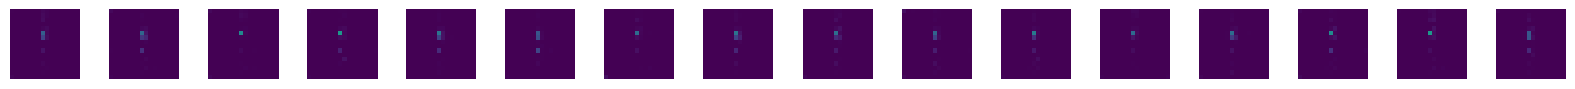

[Epoch 13/100] [D loss: 0.6986] [G loss: 0.0712] [Validity_loss: 0.6861] 
 [Stat_loss: 0.0025] [NNZ_loss: 0.0524]
Sample feature coding: [ 1.         -0.41500708  0.42367485  0.15916228  0.716447    0.00926092
  0.06548445  0.0039934   0.02649026]


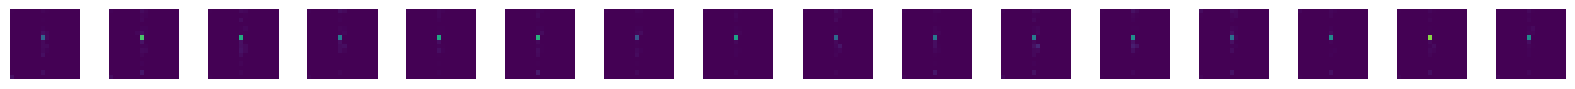

[Epoch 14/100] [D loss: 0.6884] [G loss: 0.0683] [Validity_loss: 0.7398] 
 [Stat_loss: 0.0252] [NNZ_loss: 0.0411]
Sample feature coding: [ 0.         -0.39196157  0.06016061  0.4523803   0.45271692  0.01005217
  0.02985555  0.00382413  0.03031486]


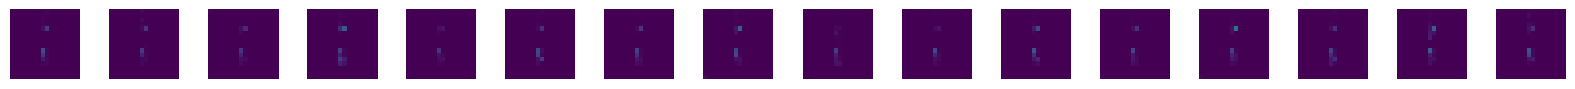

[Epoch 15/100] [D loss: 0.6913] [G loss: 0.0724] [Validity_loss: 0.6540] 
 [Stat_loss: 0.0116] [NNZ_loss: 0.0466]
Sample feature coding: [1.         1.7635413  0.15314454 0.56545496 0.5392843  0.00938438
 0.06959331 0.00376088 0.03441947]


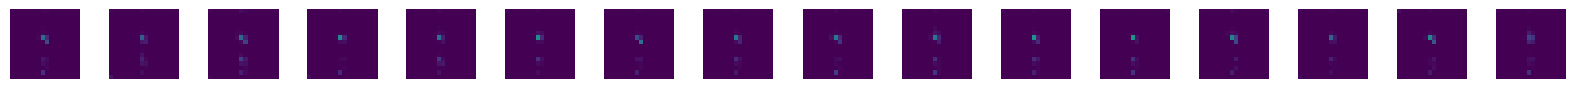

[Epoch 16/100] [D loss: 0.6861] [G loss: 0.0705] [Validity_loss: 0.7341] 
 [Stat_loss: 0.0089] [NNZ_loss: 0.0557]
Sample feature coding: [0.         0.86552614 0.9249902  0.4553684  0.5302066  0.00890601
 0.05970864 0.00399397 0.02096545]


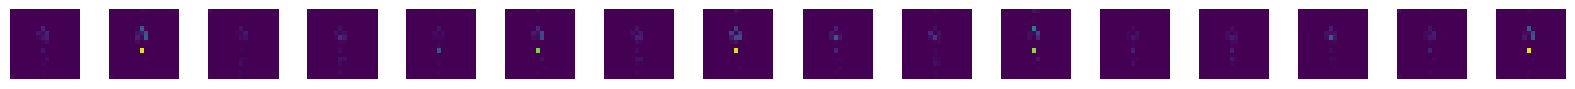

[Epoch 17/100] [D loss: 0.6978] [G loss: 0.0726] [Validity_loss: 0.6831] 
 [Stat_loss: 0.0033] [NNZ_loss: 0.0551]
Sample feature coding: [ 1.         -0.19063607  0.82656825  0.63478595  0.64541304  0.01118344
  0.06317288  0.0038036   0.03828823]


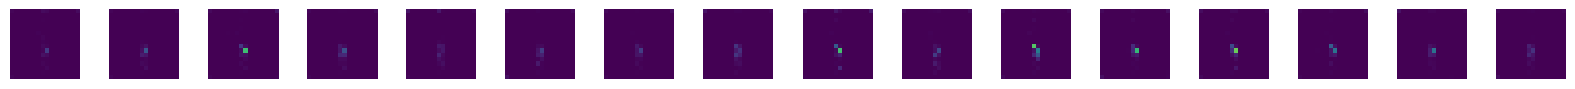

[Epoch 18/100] [D loss: 0.6789] [G loss: 0.0695] [Validity_loss: 0.7418] 
 [Stat_loss: 0.0182] [NNZ_loss: 0.0605]
Sample feature coding: [ 0.         -1.5886608   0.00161184  0.11209256  0.53295666  0.00776711
  0.05467811  0.00410656  0.02705489]


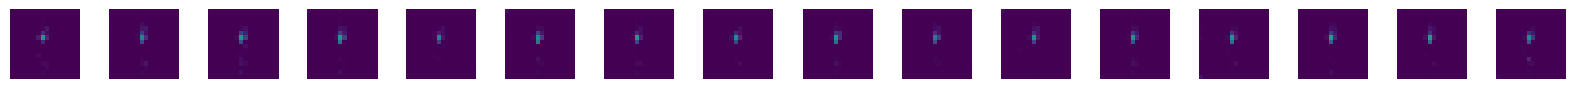

[Epoch 19/100] [D loss: 0.7156] [G loss: 0.0664] [Validity_loss: 0.7188] 
 [Stat_loss: 0.0121] [NNZ_loss: 0.0526]
Sample feature coding: [1.         0.07432715 0.9455833  0.80251896 0.7952952  0.01078134
 0.0375689  0.00385688 0.02295455]


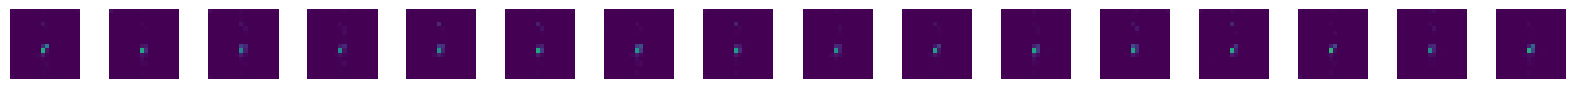

[Epoch 20/100] [D loss: 0.6820] [G loss: 0.0696] [Validity_loss: 0.7041] 
 [Stat_loss: 0.0063] [NNZ_loss: 0.0453]
Sample feature coding: [1.         0.46843675 1.0228572  0.0399815  0.89161545 0.00979989
 0.07753126 0.00401841 0.02026538]


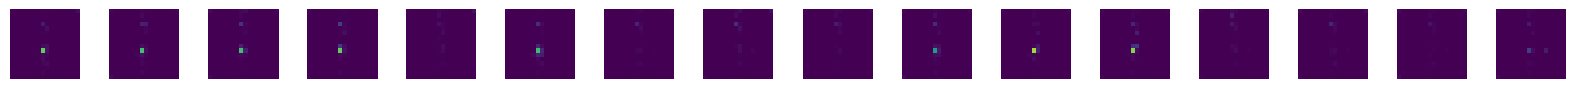

[Epoch 21/100] [D loss: 0.7077] [G loss: 0.0695] [Validity_loss: 0.7206] 
 [Stat_loss: 0.0143] [NNZ_loss: 0.0572]
Sample feature coding: [ 0.         -0.55497736  0.9656204   0.6427376   0.5519038   0.011056
  0.07204025  0.00418651  0.03124125]


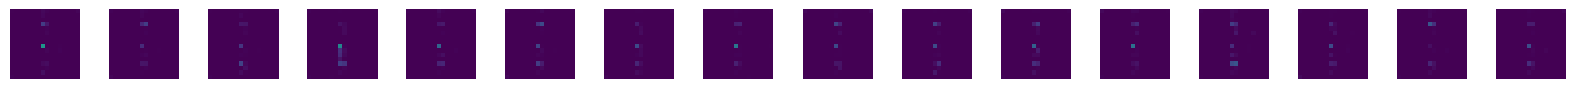

Model and statistics saved to models/Q_gan_rand_layers_temp.pt
[Epoch 22/100] [D loss: 0.6964] [G loss: 0.0716] [Validity_loss: 0.6875] 
 [Stat_loss: 0.0120] [NNZ_loss: 0.0673]
Sample feature coding: [0.         0.80595404 0.9998864  0.73508686 0.51312983 0.00838356
 0.05657224 0.0038746  0.03171749]


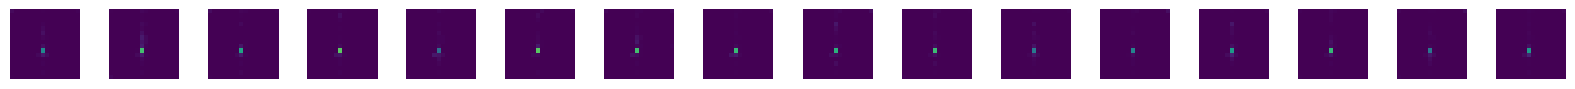

[Epoch 23/100] [D loss: 0.6738] [G loss: 0.0734] [Validity_loss: 0.7676] 
 [Stat_loss: 0.0097] [NNZ_loss: 0.0589]
Sample feature coding: [1.         1.4771305  0.44962588 0.48149997 0.5057058  0.00894161
 0.06533266 0.00371808 0.0248275 ]


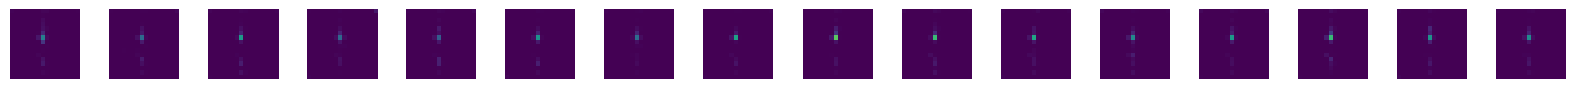

[Epoch 24/100] [D loss: 0.6898] [G loss: 0.0697] [Validity_loss: 0.8871] 
 [Stat_loss: 0.0306] [NNZ_loss: 0.0555]
Sample feature coding: [ 0.         -1.00659     0.77148664  0.8471998   0.68714446  0.00719131
  0.06809526  0.00375927  0.02365329]


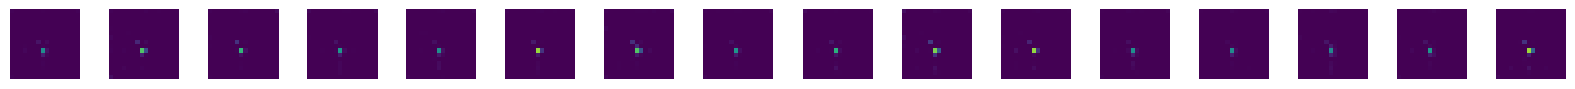

[Epoch 25/100] [D loss: 0.6868] [G loss: 0.0702] [Validity_loss: 0.6572] 
 [Stat_loss: 0.0017] [NNZ_loss: 0.0348]
Sample feature coding: [0.         0.6038796  0.45787212 0.5409614  0.58247596 0.00896942
 0.07788242 0.0037039  0.01773903]


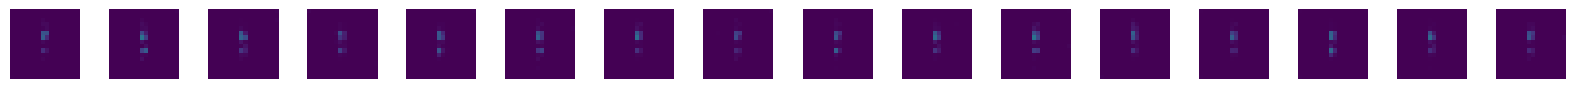

[Epoch 26/100] [D loss: 0.6793] [G loss: 0.0798] [Validity_loss: 0.6567] 
 [Stat_loss: 0.0089] [NNZ_loss: 0.0523]
Sample feature coding: [ 1.         -1.4388052   0.49829173  0.7763993   0.49575174  0.00930005
  0.06129656  0.00387784  0.05055958]


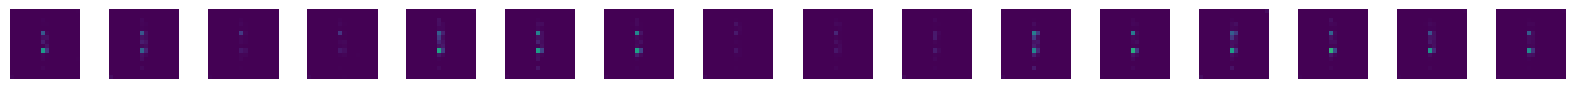

[Epoch 27/100] [D loss: 0.6989] [G loss: 0.0719] [Validity_loss: 0.7164] 
 [Stat_loss: 0.0114] [NNZ_loss: 0.0446]
Sample feature coding: [ 1.         -0.1804364   0.80444145  0.73084766  0.64852506  0.01069282
  0.05949125  0.00409913  0.02473391]


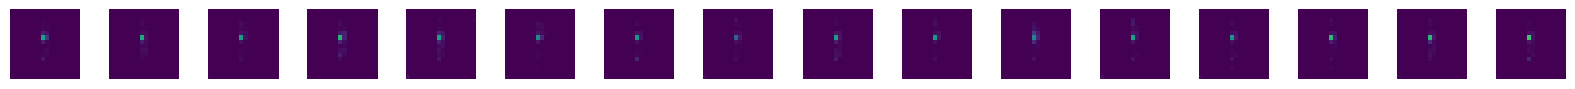

[Epoch 28/100] [D loss: 0.6876] [G loss: 0.0719] [Validity_loss: 0.6274] 
 [Stat_loss: 0.0085] [NNZ_loss: 0.0479]
Sample feature coding: [ 1.         -0.19889444  0.74953145  0.7047658   0.7356341   0.01067004
  0.05963434  0.00396665  0.03359779]


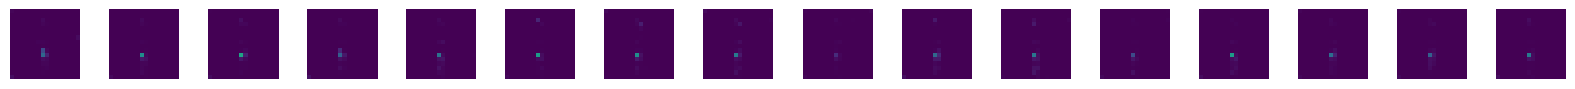

[Epoch 29/100] [D loss: 0.6651] [G loss: 0.0714] [Validity_loss: 0.5578] 
 [Stat_loss: 0.0084] [NNZ_loss: 0.0597]
Sample feature coding: [0.         1.3225605  0.6332179  0.3906359  0.55012065 0.00967217
 0.05383337 0.00429488 0.02587876]


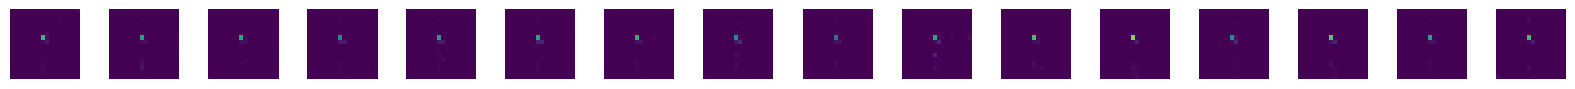

[Epoch 30/100] [D loss: 0.6965] [G loss: 0.0747] [Validity_loss: 0.3087] 
 [Stat_loss: 0.0043] [NNZ_loss: 0.0780]
Sample feature coding: [0.         0.4943123  0.6784296  0.10092341 0.427984   0.01067442
 0.0577446  0.00391969 0.03729036]


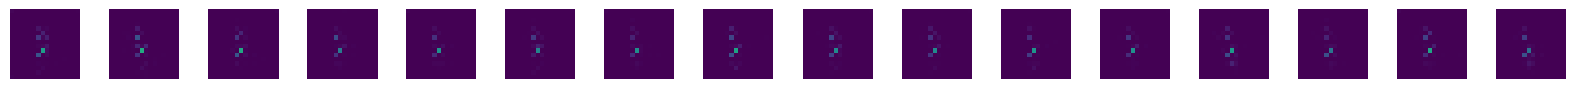

[Epoch 31/100] [D loss: 0.6716] [G loss: 0.0738] [Validity_loss: 0.7694] 
 [Stat_loss: 0.0062] [NNZ_loss: 0.0518]
Sample feature coding: [0.         0.03078423 0.30360955 0.80798256 0.6420604  0.01069151
 0.03189022 0.00390066 0.02398102]


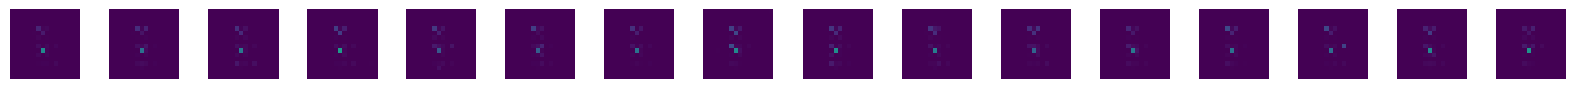

Model and statistics saved to models/Q_gan_rand_layers_temp.pt
[Epoch 32/100] [D loss: 0.6789] [G loss: 0.0710] [Validity_loss: 0.5513] 
 [Stat_loss: 0.0461] [NNZ_loss: 0.0418]
Sample feature coding: [ 0.         -0.11627118  0.6041146   0.06321695  0.5032916   0.01073684
  0.04177167  0.00436204  0.02030547]


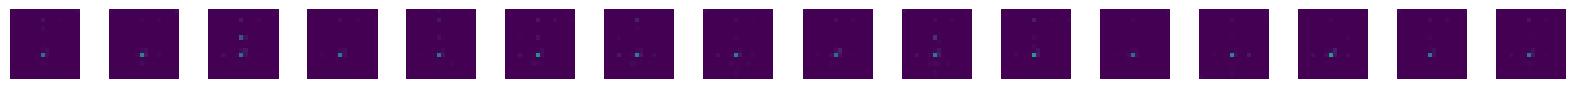

[Epoch 33/100] [D loss: 0.6903] [G loss: 0.0707] [Validity_loss: 0.7378] 
 [Stat_loss: 0.0239] [NNZ_loss: 0.0598]
Sample feature coding: [1.         1.5824692  0.7533019  0.15774603 0.62214565 0.00794358
 0.03617255 0.00425094 0.04306031]


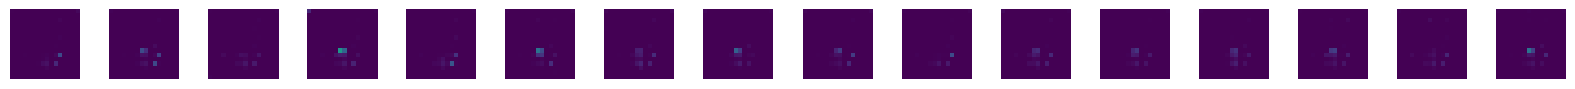

[Epoch 34/100] [D loss: 0.6935] [G loss: 0.0688] [Validity_loss: 0.6734] 
 [Stat_loss: 0.0088] [NNZ_loss: 0.0510]
Sample feature coding: [ 1.         -0.06726668  0.42671278  0.2564794   0.563116    0.01068157
  0.0613079   0.00367822  0.01756048]


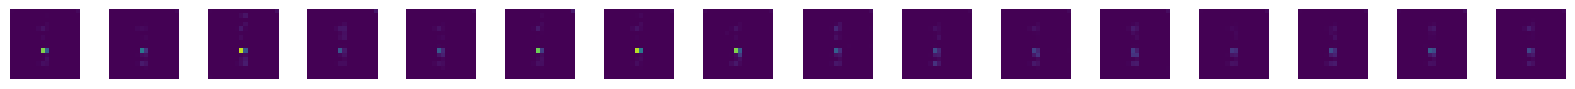

[Epoch 35/100] [D loss: 0.6757] [G loss: 0.0737] [Validity_loss: 0.6906] 
 [Stat_loss: 0.0114] [NNZ_loss: 0.0494]
Sample feature coding: [1.         0.84291756 0.10555723 0.1363086  0.54797673 0.01238528
 0.0686857  0.00354584 0.02150742]


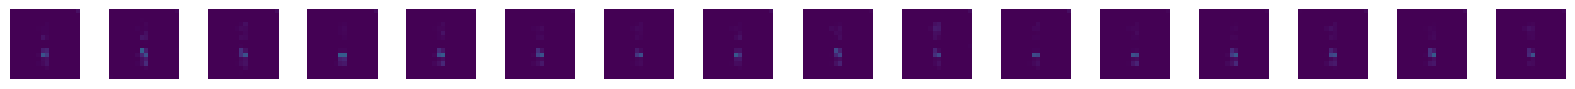

[Epoch 36/100] [D loss: 0.7098] [G loss: 0.0697] [Validity_loss: 0.6810] 
 [Stat_loss: 0.0077] [NNZ_loss: 0.0500]
Sample feature coding: [ 1.         -1.4399551   0.8855249   0.12563944  0.5485368   0.01116223
  0.07424242  0.00394941  0.04373906]


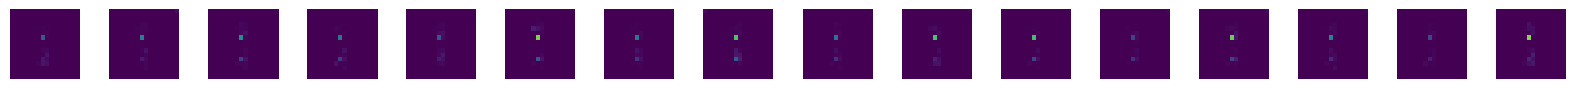

[Epoch 37/100] [D loss: 0.6799] [G loss: 0.0727] [Validity_loss: 0.7060] 
 [Stat_loss: 0.0098] [NNZ_loss: 0.0584]
Sample feature coding: [1.         0.60639596 0.66302276 0.9565424  0.64633393 0.00795679
 0.05228442 0.00422577 0.02400117]


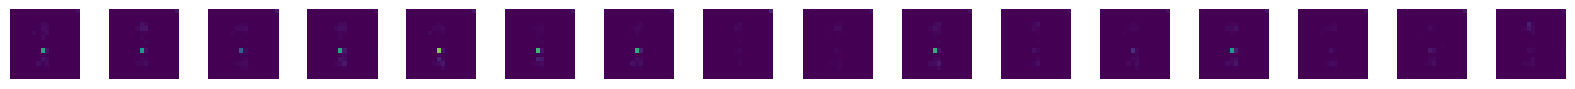

[Epoch 38/100] [D loss: 0.6993] [G loss: 0.0724] [Validity_loss: 0.8788] 
 [Stat_loss: 0.0063] [NNZ_loss: 0.0551]
Sample feature coding: [0.         0.18642151 0.98193747 0.37995514 0.5389509  0.00981341
 0.0456263  0.00419388 0.03033474]


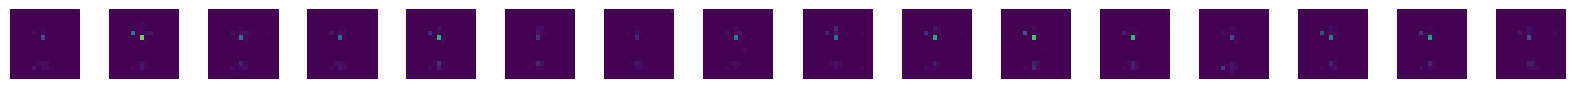

[Epoch 39/100] [D loss: 0.6764] [G loss: 0.0746] [Validity_loss: 0.8894] 
 [Stat_loss: 0.0487] [NNZ_loss: 0.0435]
Sample feature coding: [1.         0.82030773 0.7316486  0.47164446 0.6224184  0.00962554
 0.06348306 0.00390596 0.03140298]


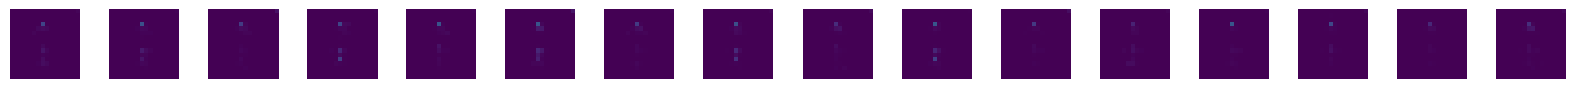

[Epoch 40/100] [D loss: 0.6627] [G loss: 0.0731] [Validity_loss: 0.7053] 
 [Stat_loss: 0.0079] [NNZ_loss: 0.0471]
Sample feature coding: [ 0.         -1.4868698   0.81797945  0.58546805  0.66056484  0.00927356
  0.06065955  0.00412555  0.03635146]


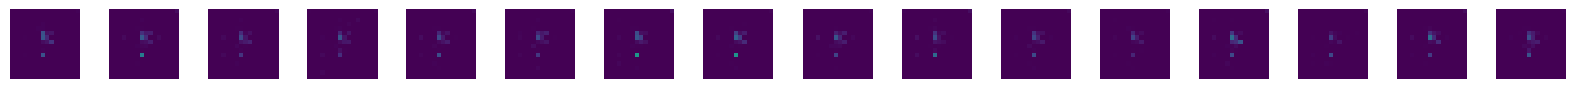

[Epoch 41/100] [D loss: 0.6782] [G loss: 0.0748] [Validity_loss: 0.7145] 
 [Stat_loss: -0.0004] [NNZ_loss: 0.0509]
Sample feature coding: [1.         1.3240944  0.7592218  0.3685402  0.47392517 0.01120837
 0.07688707 0.00374599 0.02518657]


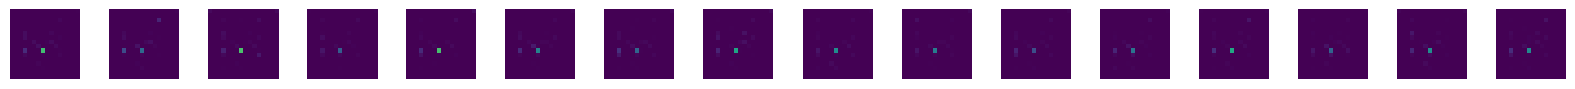

Model and statistics saved to models/Q_gan_rand_layers_temp.pt
[Epoch 42/100] [D loss: 0.6978] [G loss: 0.0772] [Validity_loss: 0.5860] 
 [Stat_loss: 0.0103] [NNZ_loss: 0.0436]
Sample feature coding: [ 1.         -0.66399854  0.8318871   0.6108398   0.54302657  0.00622501
  0.05873178  0.00399257  0.03519903]


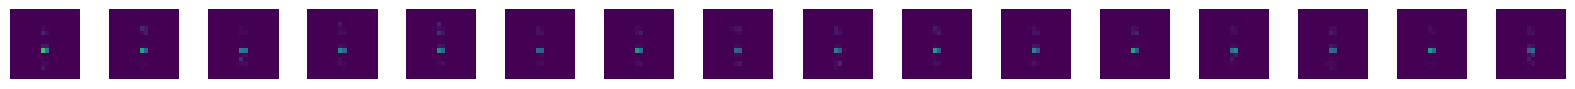

[Epoch 43/100] [D loss: 0.6713] [G loss: 0.0754] [Validity_loss: 0.8783] 
 [Stat_loss: 0.0449] [NNZ_loss: 0.0545]
Sample feature coding: [1.         0.9475101  0.6270886  0.55360824 0.5057418  0.01114301
 0.07270312 0.00414843 0.02555041]


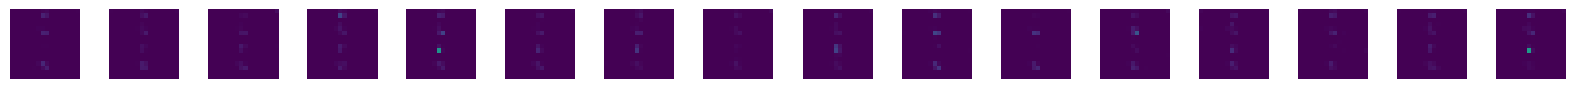

[Epoch 44/100] [D loss: 0.6850] [G loss: 0.0739] [Validity_loss: 0.5768] 
 [Stat_loss: 0.0283] [NNZ_loss: 0.0522]
Sample feature coding: [0.         0.17451835 0.2827717  0.04472508 0.50589657 0.0107202
 0.05712027 0.00408099 0.01579494]


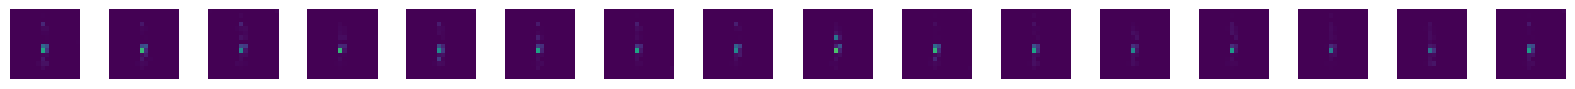

[Epoch 45/100] [D loss: 0.6621] [G loss: 0.0752] [Validity_loss: 0.6681] 
 [Stat_loss: 0.0014] [NNZ_loss: 0.0571]
Sample feature coding: [0.         0.4901862  0.6781338  0.535646   0.508111   0.01020342
 0.0420708  0.0040489  0.03882146]


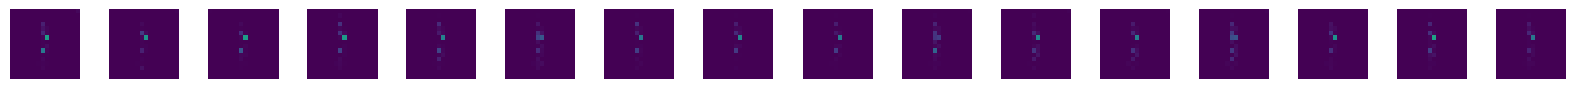

[Epoch 46/100] [D loss: 0.6649] [G loss: 0.0730] [Validity_loss: 0.6504] 
 [Stat_loss: 0.0044] [NNZ_loss: 0.0664]
Sample feature coding: [0.         1.150757   0.44522578 0.5628384  0.6379762  0.00951646
 0.0587827  0.00422087 0.0394806 ]


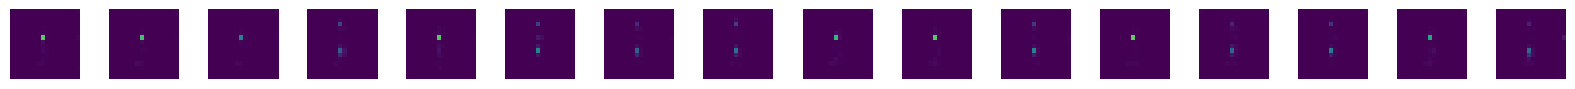

[Epoch 47/100] [D loss: 0.6817] [G loss: 0.0723] [Validity_loss: 0.8211] 
 [Stat_loss: 0.0189] [NNZ_loss: 0.0431]
Sample feature coding: [1.         0.42472658 0.84098136 0.12690955 0.60902923 0.00931621
 0.05656399 0.00407488 0.03315536]


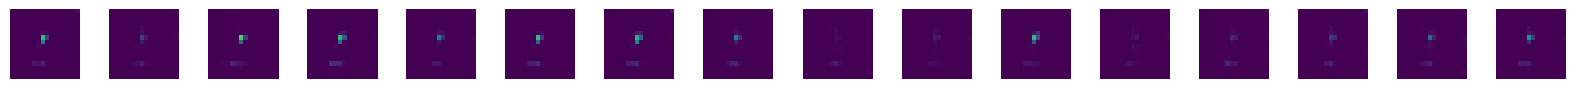

[Epoch 48/100] [D loss: 0.6839] [G loss: 0.0770] [Validity_loss: 0.6178] 
 [Stat_loss: 0.0129] [NNZ_loss: 0.0506]
Sample feature coding: [1.         1.7305465  0.8777185  0.34464902 0.64408934 0.00995373
 0.07622118 0.0040173  0.04453384]


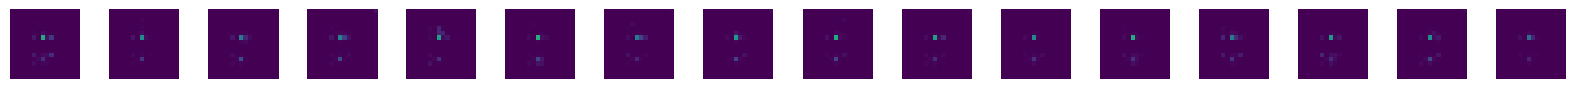

[Epoch 49/100] [D loss: 0.6698] [G loss: 0.0770] [Validity_loss: 0.8370] 
 [Stat_loss: 0.0185] [NNZ_loss: 0.0536]
Sample feature coding: [ 1.         -1.0252576   0.58182186  0.67817235  0.7310776   0.00964845
  0.08581102  0.00425171  0.03260339]


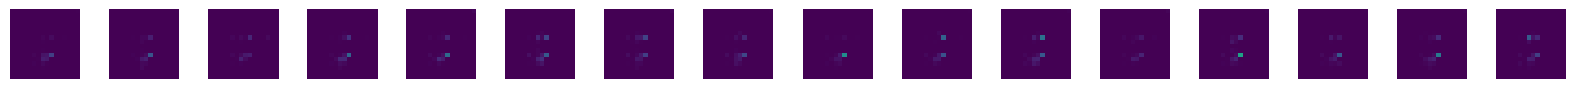

[Epoch 50/100] [D loss: 0.6870] [G loss: 0.0751] [Validity_loss: 0.8427] 
 [Stat_loss: 0.0695] [NNZ_loss: 0.0549]
Sample feature coding: [ 1.         -0.5978554   0.13206124  0.76717705  0.65114725  0.0093735
  0.06665556  0.00360511  0.03627616]


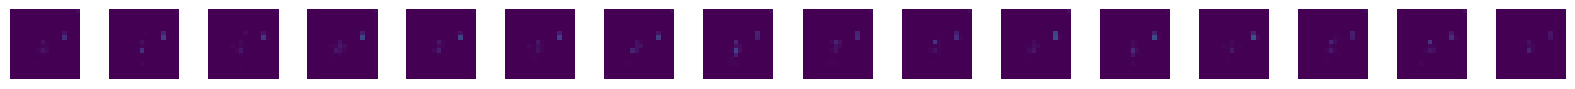

[Epoch 51/100] [D loss: 0.6504] [G loss: 0.0721] [Validity_loss: 0.6091] 
 [Stat_loss: 0.0042] [NNZ_loss: 0.0479]
Sample feature coding: [0.         1.9190484  0.3997146  0.16085124 0.50685894 0.01051525
 0.07106581 0.00398756 0.02681096]


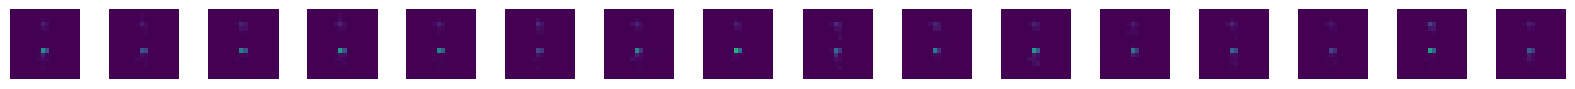

Model and statistics saved to models/Q_gan_rand_layers_temp.pt


KeyboardInterrupt: 

In [8]:
if True:
    for epoch in range(n_epochs):
        for i, (real_image, real_features, flipped_image, flipped_features) in enumerate(dataloader):
            
            # All real data are normalized in the dataloader
            real_feat = real_features.cuda()
            real_flipped_feat = flipped_features.cuda()
            real_img = real_image.unsqueeze(1).cuda()
            real_flipped_img = flipped_image.unsqueeze(1).cuda()
    
            # print(f"Real: {real_img.shape}")
    
            # Codings should be label, eta, pT, mass that get passed directly to the discriminator
            # Other values are pure noise and get passed to the generator, then those outputs passed to the discriminator
    
            # Discriminator training
            if i % 3 == 0:
                optimizer_D.zero_grad()
                discriminator.train()
                # Generate fake samples
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).cuda()
                # z_noise = torch.randn(batch_size, 5, ).cuda()
                # z_codings = torch.cat([z_codings, z_noise], dim=1)
    
                # Discriminator gets z_codings + generated_features
                fake_img = generator(z_codings)
                # print(f"Fake: {fake_img.shape}")
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1
                
                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                real_disc_codings = real_feat[:,:num]
                real_flipped_disc_codings = real_flipped_feat[:,:num]
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]
    
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)
    
                preds = (torch.cat([real_pred, real_flipped_pred, fake_pred, fake_flipped_pred], dim=0)).squeeze(1)
    
    
                # real_labels = torch.empty_like(real_pred).uniform_(0.7, 1.2)
                # fake_labels = torch.empty_like(fake_pred).uniform_(0.0, 0.3)
                # labels = (torch.cat([real_labels, fake_labels], dim=0)).cuda()
    
                ones = torch.ones(2*len(fake_pred))
                zeros = torch.zeros(2*len(real_pred))
                labels = (torch.cat([ones, zeros], dim=0)).cuda()
    
                # Discriminator loss is just its ability to distinguish
                d_loss = torch.nn.BCELoss()(preds, labels)
    
                d_loss.backward()
                optimizer_D.step()
    
            # Generator Training
            if i % 1 == 0:
                optimizer_G.zero_grad()
                # generator.train()
                
                # Generate fake data
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).cuda()
                # z_noise = torch.randn(batch_size, 5, ).cuda()
                # z_codings = torch.cat([z_codings, z_noise], dim=1)
    
                # Discriminator gets z_codings + generated_features
                fake_img = generator(z_codings)
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1
                
                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]
                
                # Fooled discriminator loss
                d_out = discriminator(fake_img, fake_disc_codings)
                d_out_flip = discriminator(fake_flipped_img, fake_flipped_disc_codings)
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                
                target = torch.ones_like(d_out)
                bce = nn.BCELoss()
                validity_loss = bce(d_out, target) + bce(d_out_flip, target)
                
                # ----- Fake ΔR Calculation -----
                # Original
                # Weighted: pixel * distance / sum(pixel)
                weights = fake_img.squeeze(1)
    
                dR = (weights * dists)
    
                fake_dR_mean = dR.mean(dim = (1,2))
                fake_dR_std = dR.std(dim = (1,2))
                
                # Pixel stats
                fake_pixel_mean = weights.mean(dim = (1,2))
                fake_pixel_std = weights.std(dim = (1,2))
                
                # Flipped
                # Weighted: pixel * distance / sum(pixel)
                weights = fake_flipped_img.squeeze(1)
                dR = (weights * dists)
    
                flipped_dR_mean = dR.mean(dim = (1,2))
                flipped_dR_std = dR.std(dim = (1,2))
                
                # Pixel stats
                flipped_pixel_mean = weights.squeeze(1).mean(dim = (1,2))
                flipped_pixel_std = weights.squeeze(1).std(dim = (1,2))
    
                real_dR_mean = z_codings[:,5]
                real_dR_std = z_codings[:,6]
                real_pixel_mean = z_codings[:,7]
                real_pixel_std = z_codings[:,8]
    
    
                # Statistical MSE loss
                # dR_mean_loss = (torch.nn.MSELoss()(fake_dR_mean, real_dR_mean) + torch.nn.MSELoss()(flipped_dR_mean, real_dR_mean))
                # dR_std_loss = (torch.nn.MSELoss()(fake_dR_std, real_dR_std) + torch.nn.MSELoss()(flipped_dR_std, real_dR_std))
                # pixel_mean_loss = (torch.nn.MSELoss()(fake_pixel_mean, real_pixel_mean) + torch.nn.MSELoss()(flipped_pixel_mean, real_pixel_mean))
                # pixel_std_loss = (torch.nn.MSELoss()(fake_pixel_std, real_pixel_std) + torch.nn.MSELoss()(flipped_pixel_std, real_pixel_std))
                
                # stat_loss = dR_mean_loss + dR_std_loss + 3*pixel_mean_loss + 2*pixel_std_loss
    
                # print(dR_mean_loss)
                # print(dR_std_loss)
                # print(3*pixel_mean_loss)
                # print(2*pixel_std_loss)
    
                # Statistical KL Divergence loss
                kl_total = 0
                kl_total += kde_kl_divergence_torch(real_dR_mean, fake_dR_mean) / .001
                kl_total += kde_kl_divergence_torch(real_dR_std, fake_dR_std) / .03
                kl_total += kde_kl_divergence_torch(real_pixel_mean, fake_pixel_mean) / .0001
                kl_total += kde_kl_divergence_torch(real_pixel_std, fake_pixel_std) / .01
    
                stat_loss = kl_total
    
                # Number non-zero loss
                fake_nnz = soft_count_nonzero(fake_img, threshold=3e-3, sharpness=10000.0)
                real_nnz = soft_count_nonzero(real_img, threshold=3e-3, sharpness=10000.0)
                nnz_loss = torch.nn.MSELoss()(fake_nnz, real_nnz)
    
                
                # Total generator loss is the average of the discriminator's predictions of the original and flipped data
                # + the difference between input and output dR and pixel statistics
    
                alpha = .4
                beta = .001
                chi = 3
    
                g_loss = (alpha*validity_loss + beta*nnz_loss + chi*stat_loss)
    
                g_loss.backward()
                optimizer_G.step()
    
                if n_epochs - epoch <= 10:
                    # Track fake stats
                    tracked_fake_dR_mean.append(fake_dR_mean.detach().cpu())
                    tracked_fake_dR_std.append(fake_dR_std.detach().cpu())
                    tracked_fake_pixel_mean.append(fake_pixel_mean.detach().cpu())
                    tracked_fake_pixel_std.append(fake_pixel_std.detach().cpu())
                    
                    # Track real stats from z_codings
                    tracked_real_dR_mean.append(z_codings[:,5].detach().cpu())
                    tracked_real_dR_std.append(z_codings[:,6].detach().cpu())
                    tracked_real_pixel_mean.append(z_codings[:,7].detach().cpu())
                    tracked_real_pixel_std.append(z_codings[:,8].detach().cpu())
    
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
    
        print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {d_losses[epoch]:.4f}] [G loss: {g_losses[epoch]:.4f}] [Validity_loss: {alpha*validity_loss:.4f}] \n [Stat_loss: {chi*stat_loss:.4f}] [NNZ_loss: {beta*nnz_loss:.4f}]") 
    
        z_img = torch.randn(batch_size, 256, 1, 1).cuda()
    
        # Should be very easy to modify which values are passed as codings
        z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                              sample_fit_noise(kdes, num_samples=batch_size)],
                              dim=1).cuda()
        # z_noise = torch.randn(batch_size, 5, ).cuda()
        # z_feat1 = torch.cat([z_codings, z_noise], dim=1)
        z_feat = torch.cat([z_codings], dim=1)
    
        fake_images = generator(z_feat)
        fake_feat = z_codings
        fake_images.detach().cpu()
        fake_feat.detach().cpu()
        # real_images = next(iter(dataloader))[0][:1000].cpu()
    
        # output_image = fake_images[:16]  # Save 16 generated samples
        # output_image = (output_image + 1) / 2.0  # Scale to [0, 1]
        # grid = (torchvision.utils.make_grid(output_image, nrow=4, normalize=True)).cpu()
        # np_img = grid.permute(1, 2, 0).numpy()
        # plt.imsave(f'classical_Jet_image_epoch_{epoch}.png', np_img)
        plot_generated_samples(generator, dataset, kdes, batch_size=16, latent_dim=256)

        if epoch % 10 == 0:
            os.makedirs("models", exist_ok=True)

            # Save model states and tracked data in a single file
            save_path = f"models/Q_gan_rand_layers_temp.pt"
            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "g_losses": g_losses,
                "d_losses": d_losses,
                "tracked_fake_dR_mean": tracked_fake_dR_mean,
                "tracked_fake_dR_std": tracked_fake_dR_std,
                "tracked_fake_pixel_mean": tracked_fake_pixel_mean,
                "tracked_fake_pixel_std": tracked_fake_pixel_std,
                "tracked_real_dR_mean": tracked_real_dR_mean,
                "tracked_real_dR_std": tracked_real_dR_std,
                "tracked_real_pixel_mean": tracked_real_pixel_mean,
                "tracked_real_pixel_std": tracked_real_pixel_std
            }, save_path)
            
            print(f"Model and statistics saved to {save_path}")
    
    plot_metrics(g_losses, d_losses)
    
    ## Last 10 epochs stats
    # Flatten all batches
    fake_dR_mean_vals = torch.cat(tracked_fake_dR_mean).numpy() / batch_size
    fake_dR_std_vals = torch.cat(tracked_fake_dR_std).numpy() / batch_size
    fake_pixel_mean_vals = torch.cat(tracked_fake_pixel_mean).numpy() / batch_size
    fake_pixel_std_vals = torch.cat(tracked_fake_pixel_std).numpy() / batch_size
    
    real_dR_mean_vals = torch.cat(tracked_real_dR_mean).numpy() / batch_size
    real_dR_std_vals = torch.cat(tracked_real_dR_std).numpy() / batch_size
    real_pixel_mean_vals = torch.cat(tracked_real_pixel_mean).numpy() / batch_size
    real_pixel_std_vals = torch.cat(tracked_real_pixel_std).numpy() / batch_size
    
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))  # 4 stats
    
    stat_titles = ['ΔR Mean', 'ΔR Std', 'Pixel Mean', 'Pixel Std']
    real_stats = [real_dR_mean_vals, real_dR_std_vals, real_pixel_mean_vals, real_pixel_std_vals]
    fake_stats = [fake_dR_mean_vals, fake_dR_std_vals, fake_pixel_mean_vals, fake_pixel_std_vals]
    
    for row in range(4):
        ax = axs[row]
    
        real_vals = real_stats[row]
        fake_vals = fake_stats[row]
    
        # Compute limits
        lower = min(np.percentile(real_vals, 1), np.percentile(fake_vals, 1))
        upper = max(np.percentile(real_vals, 99), np.percentile(fake_vals, 99))
    
        # Truncate values
        real_vals_trunc = real_vals[(real_vals >= lower) & (real_vals <= upper)]
        fake_vals_trunc = fake_vals[(fake_vals >= lower) & (fake_vals <= upper)]
    
        # Plot
        ax.hist(real_vals_trunc, bins=1000, alpha=0.6, label='Real',
                edgecolor='black', density=True, histtype='stepfilled')
        ax.hist(fake_vals_trunc, bins=1000, alpha=0.6, label='Fake',
                edgecolor='black', density=True, histtype='stepfilled')
    
        ax.set_xlim(lower, upper)
        ax.set_title(f"{stat_titles[row]}")
        ax.legend()
    
    plt.tight_layout()
    plt.suptitle("Real vs Fake Distributions by Statistic", fontsize=16, y=1.02)
    plt.show()

In [9]:
save = True

if save:
    os.makedirs("models", exist_ok=True)

    # Timestamp for unique filenames
    timestamp = datetime.now().strftime("m%d_%H%M")
    
    # Save model states and tracked data in a single file
    save_path = f"models/Q_gan_rand_layers_{timestamp}.pt"
    torch.save({
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "tracked_fake_dR_mean": tracked_fake_dR_mean,
        "tracked_fake_dR_std": tracked_fake_dR_std,
        "tracked_fake_pixel_mean": tracked_fake_pixel_mean,
        "tracked_fake_pixel_std": tracked_fake_pixel_std,
        "tracked_real_dR_mean": tracked_real_dR_mean,
        "tracked_real_dR_std": tracked_real_dR_std,
        "tracked_real_pixel_mean": tracked_real_pixel_mean,
        "tracked_real_pixel_std": tracked_real_pixel_std
    }, save_path)
    
    print(f"Model and statistics saved to {save_path}")

Model and statistics saved to models/Q_gan_rand_layers_m21_1016.pt


![image.png](attachment:7aee3b98-579c-4bcb-9682-eb417b7e3a7a.png)

In [ ]:
plot_real_samples(dataset)

Sample feature coding: [ 0.         -1.546888    0.9108667   0.37212434  0.912077    0.01024187
  0.05150609  0.00378909  0.03779316]


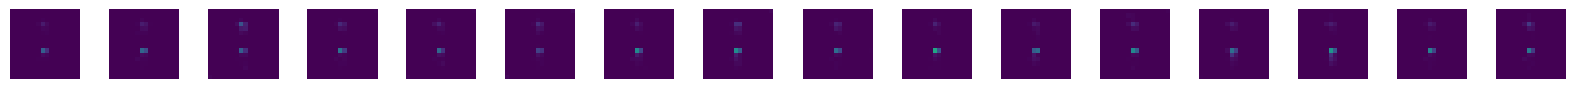

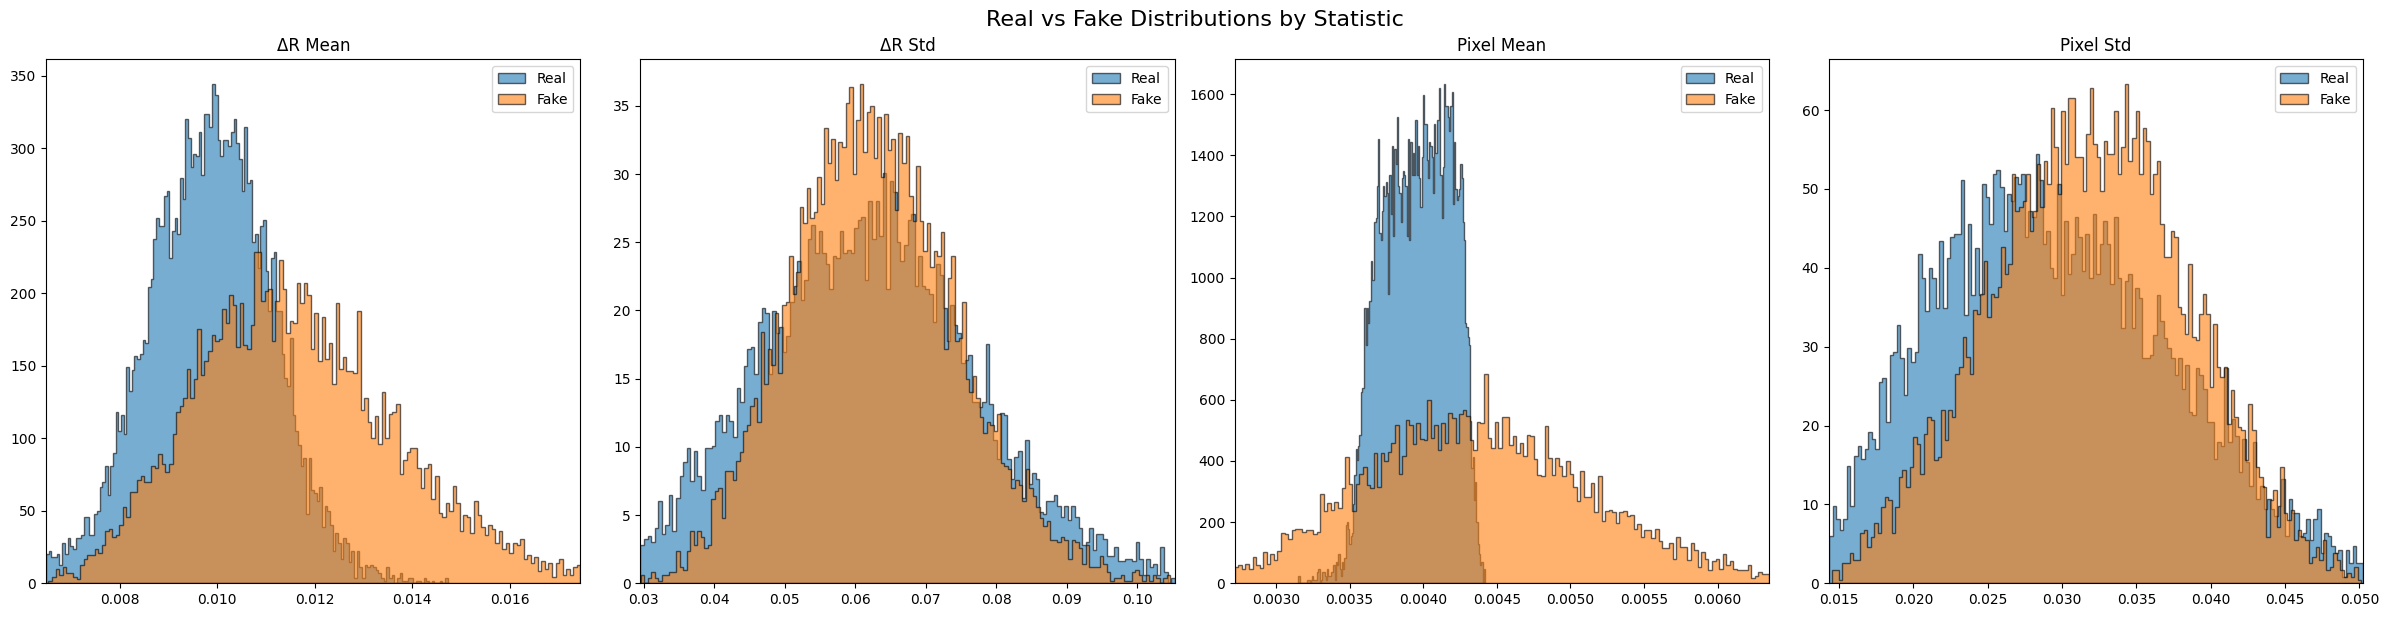

Discriminator output (wrong label): [0.34612852 0.28789654 0.36022073 ... 0.4656085  0.33302078 0.38916013]
Discriminator output (correct label): [0.5311192  0.57984453 0.56596595 ... 0.556496   0.571828   0.47968617]
Real labels: [1. 1. 1. ... 1. 1. 1.]
Swapped labels: [0. 0. 0. ... 0. 0. 0.]
Relative change (%): [-34.830357 -50.349354 -36.352932 ... -16.332108 -41.762074 -18.871933]


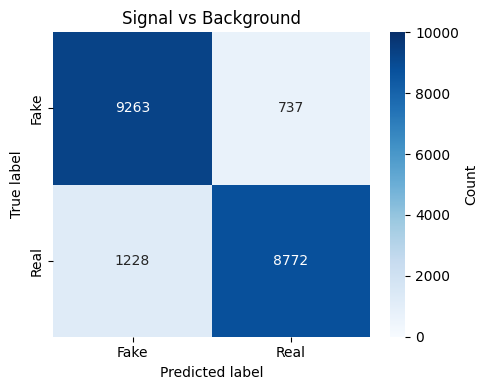

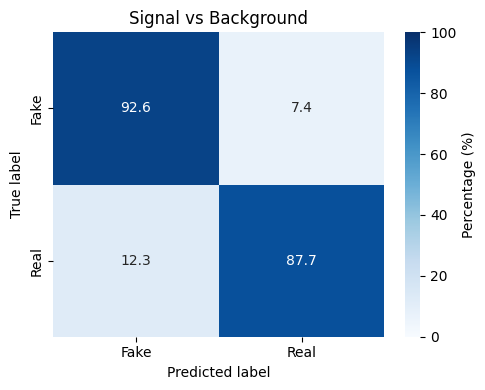

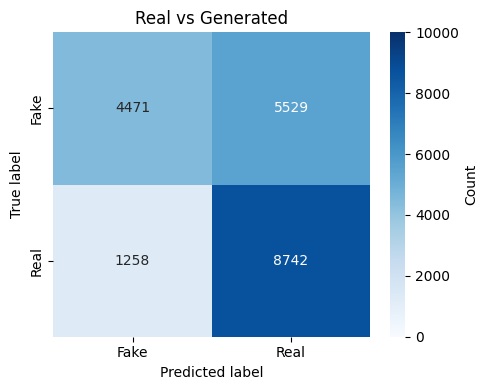

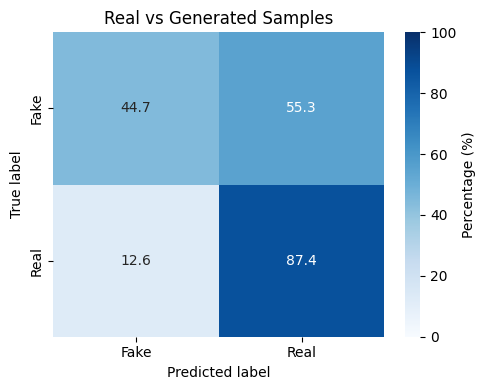

In [10]:
test_generated_samples(generator, discriminator, dataset, kdes, batch_size=10000)

# Optional args:
#     generator,
#     discriminator,
#     dataset,
#     kdes,
#     batch_size=16,
#     latent_dim=256,
#     codings=None,
#     plot_distributions=True,
#     compare_discriminator=True